It is said that over the long run the returns of major global equity indices have correlations that are close to 1. This notebook investigates that claim.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [57]:
global_equity_indices = {
    "S&P 500": "^GSPC",
    "Russell 3000": "^RUA",
    "NASDAQ Composite": "^IXIC",
  

    "FTSE 100": "^FTSE",
    "DAX 40": "^GDAXI",
    "CAC 40": "^FCHI",

    "Nikkei 225": "^N225",
    "Hang Seng Index": "^HSI",

    "TSX Composite": "^GSPTSE",


}

index_currency = {
    "S&P 500": "USD",
    "Russell 3000": "USD",
    "NASDAQ Composite": "USD",

    "FTSE 100": "GBP",
    "DAX 40": "EUR",
    "CAC 40": "EUR",
    "Nikkei 225": "JPY",
    "Hang Seng Index": "HKD",

    "TSX Composite": "CAD",

}

# FX pairs used to convert local-currency index levels into USD terms
# invert=True means the Yahoo pair is quoted as local currency per USD and must be inverted.
currency_fx = {
    "EUR": ("EURUSD=X", False),
    "GBP": ("GBPUSD=X", False),
    "AUD": ("AUDUSD=X", False),
    "JPY": ("JPY=X", True),
    "HKD": ("HKD=X", True),
    "CAD": ("CAD=X", True),
    "CNY": ("CNY=X", True),
    "INR": ("INR=X", True),
    "BRL": ("BRL=X", True)
}

tickers = list(global_equity_indices.values())
raw_data = yf.download(tickers, start="1990-01-01", end="2026-05-05")["Close"]
ticker_to_name = {v: k for k, v in global_equity_indices.items()}
data_local = raw_data.rename(columns=ticker_to_name)

needed_currencies = sorted({ccy for ccy in index_currency.values() if ccy != "USD"})
fx_tickers = [currency_fx[ccy][0] for ccy in needed_currencies]
fx_raw = yf.download(fx_tickers, start="1990-01-01", end="2026-05-05")["Close"]

if isinstance(fx_raw, pd.Series):
    fx_raw = fx_raw.to_frame()

fx_raw = fx_raw.ffill()
fx_usd_factor = pd.DataFrame(index=data_local.index)
for ccy in needed_currencies:
    fx_ticker, invert = currency_fx[ccy]
    series = fx_raw[fx_ticker]
    fx_usd_factor[ccy] = 1 / series if invert else series

# USD-adjusted index levels
data = data_local.copy()
for index_name, ccy in index_currency.items():
    if ccy != "USD":
        data[index_name] = data[index_name] * fx_usd_factor[ccy]

[*********************100%***********************]  9 of 9 completed
[*********************100%***********************]  5 of 5 completed


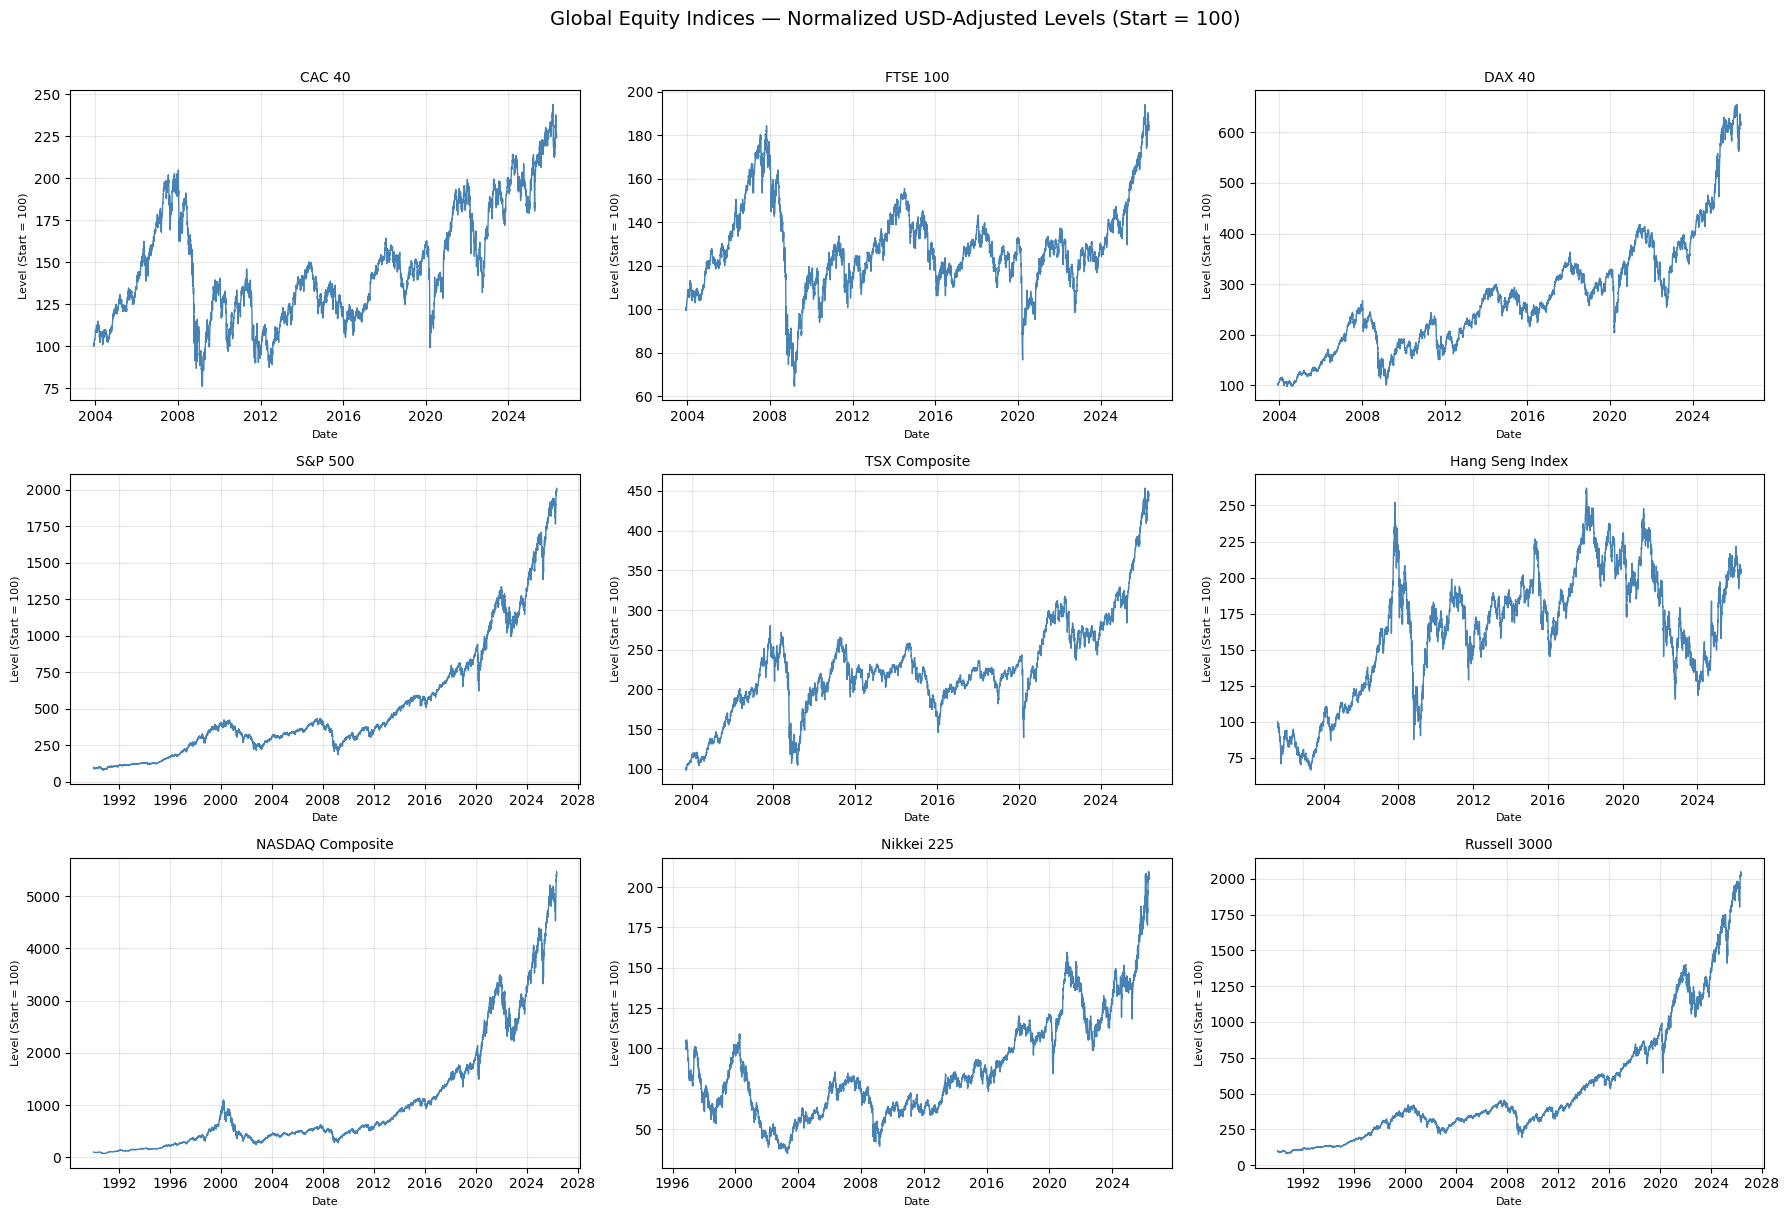

In [58]:
import math

n_indices = len(data.columns)
n_cols = 3
n_rows = math.ceil(n_indices / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(data.columns):
    series = data[col].dropna()
    normalized = series / series.iloc[0] * 100
    axes[i].plot(series.index, normalized, linewidth=1, color="steelblue")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Date", fontsize=8)
    axes[i].set_ylabel("Level (Start = 100)", fontsize=8)
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Global Equity Indices — Normalized USD-Adjusted Levels (Start = 100)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

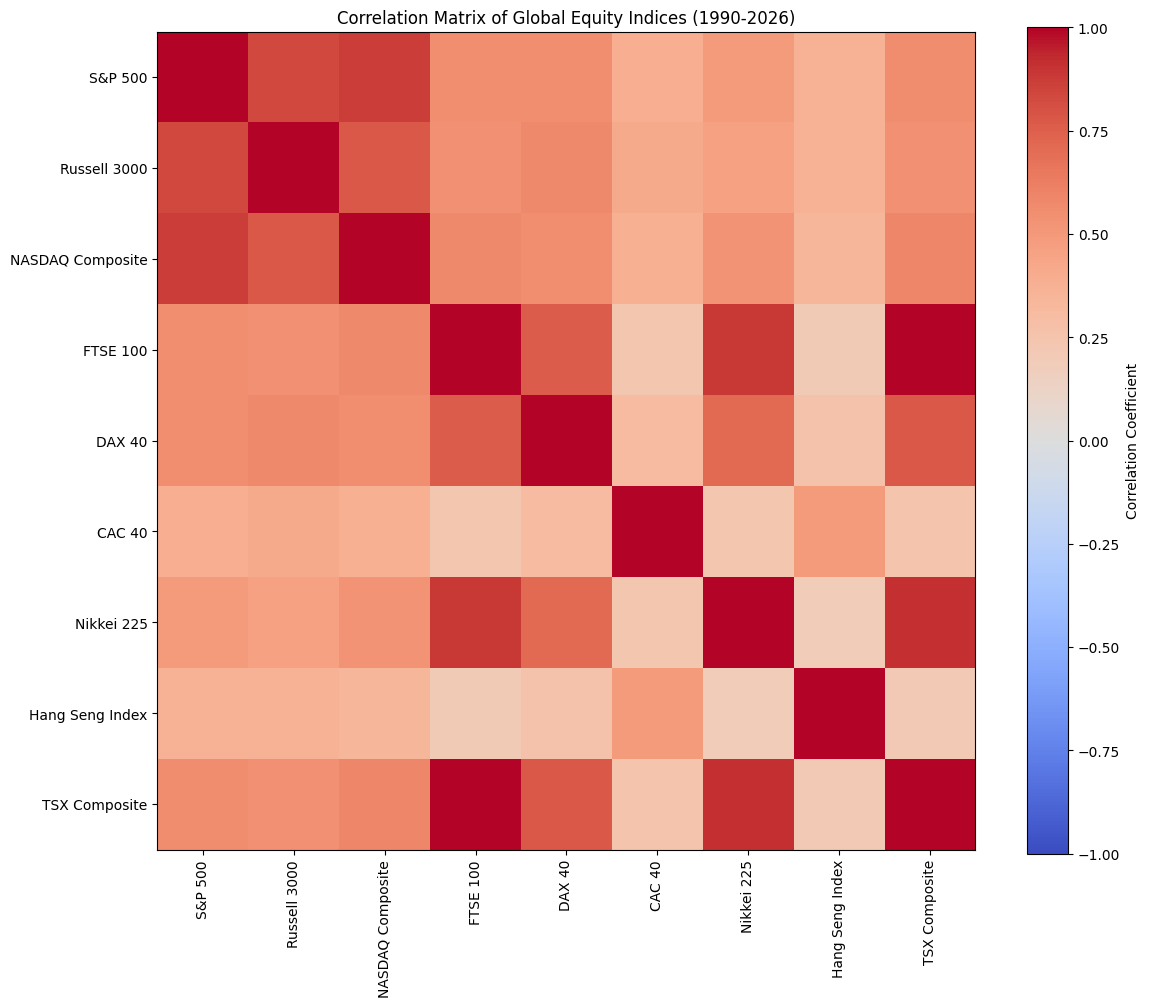

In [59]:
data_local.dropna(inplace=True)
log_returns = np.log(data_local / data_local.shift(1)).dropna()
correlation_matrix = log_returns.corr()
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")
plt.xticks(ticks=np.arange(len(global_equity_indices)), labels=global_equity_indices.keys(), rotation=90)
plt.yticks(ticks=np.arange(len(global_equity_indices)), labels=global_equity_indices.keys())
plt.title("Correlation Matrix of Global Equity Indices (1990-2026)")
plt.tight_layout()
plt.show()

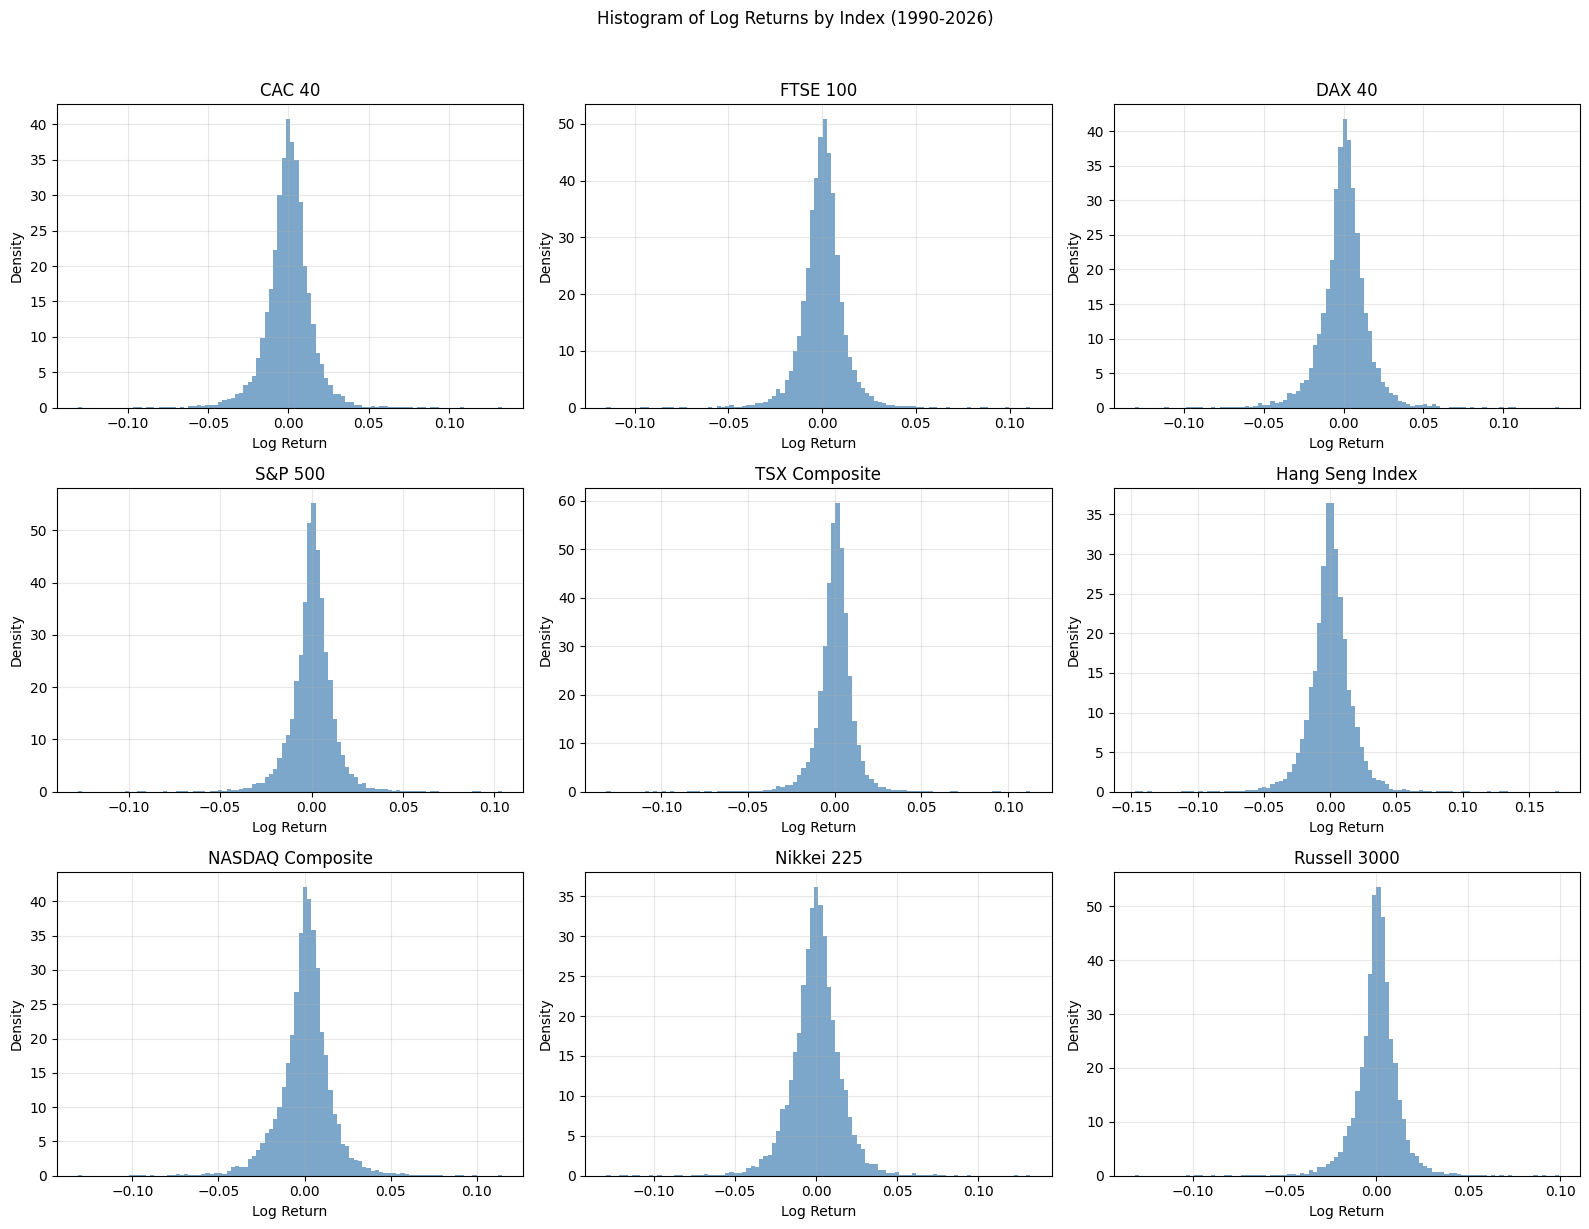

In [60]:
import math

n_series = log_returns.shape[1]
n_cols = 3
n_rows = math.ceil(n_series / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(log_returns.columns):
    series = log_returns[col].dropna()
    axes[i].hist(series, bins=100, density=True, alpha=0.7, color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("Log Return")
    axes[i].set_ylabel("Density")
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogram of Log Returns by Index (1990-2026)", y=1.02)
fig.tight_layout()
plt.show()